In [10]:
from jax.scipy.stats import norm, poisson
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt


In [11]:
def model(x0, theta, key, t_range):
    delta_t = t_range[1] - t_range[0]

    log_gamma,log_xi, log_mean = theta

    gamma = jnp.exp(log_gamma)
    xi = jnp.exp(log_xi)
    damping = 1/35
    std = 0.2

    log_beta_damping = damping
    log_beta_mean = log_mean
    log_beta_standard_deviation = std

    A = jnp.exp(-log_beta_damping * delta_t)
    M = log_beta_mean * (jnp.exp(-log_beta_damping * delta_t) - 1)
    C = log_beta_standard_deviation * jnp.sqrt(
        1 - jnp.exp(-2 * log_beta_damping * delta_t)
    )

    def tau_step(state, i):
        prev_x, prev_key = state
        S, I, R, log_beta = prev_x

        N = S + I + R

        update_key, next_key = jax.random.split(prev_key, 2)
        update_keys = jax.random.split(update_key, 4)

        log_beta = A * log_beta - M + C * jax.random.normal(update_keys[0])

        dN_SI = jax.random.poisson(
            update_keys[1], jnp.exp(log_beta) * (S * I / N) * delta_t
        )
        dN_SI = jnp.minimum(dN_SI, S)

        dN_IR = jax.random.poisson(update_keys[2], I * gamma * delta_t)
        dN_IR = jnp.minimum(dN_IR, I)

        dN_RS = jax.random.poisson(update_keys[3], R * xi * delta_t)
        dN_RS = jnp.minimum(dN_RS, R)

        S = S - dN_SI + dN_RS
        I = I + dN_SI - dN_IR
        R = R + dN_IR - dN_RS

        return (jnp.array([S, I, R, log_beta]), next_key), jnp.array(
            [S, I, R, log_beta]
        )

    _, loop_val = jax.lax.scan(
        tau_step,
        init=(x0, key),
        xs=t_range[1:],
    )

    return jnp.concatenate((x0[jnp.newaxis, :], loop_val))

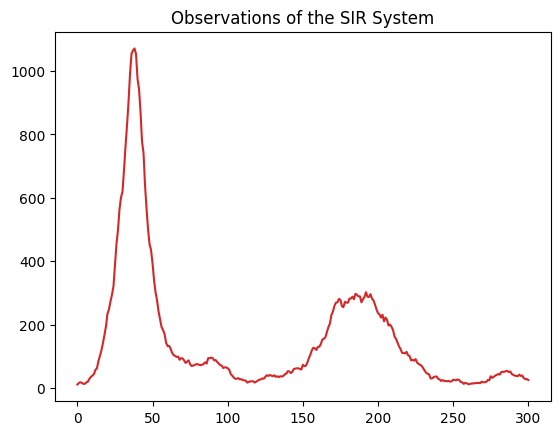

In [ ]:
theta = jnp.array(
    [jnp.log(0.2), jnp.log(1 / 90), jnp.log(0.7)]
)
delta_t = 1.0
days = 300
rng_key = jax.random.key(0)
t_range = jnp.arange(0, days + delta_t, delta_t)

SIR_init_key, rng_key = jax.random.split(rng_key)
beta_init_key, rng_key = jax.random.split(rng_key)
I_x0 = jax.random.randint(SIR_init_key, minval=0, maxval=20, shape=())

x0 = jnp.full(shape=(3), fill_value=jnp.array([5000, 0, 0]))

x0 = x0.at[0].set(x0[0] - I_x0)
x0 = x0.at[1].set(x0[1] + I_x0)

beta_x0 = jax.random.uniform(beta_init_key, shape=(), minval=0.1, maxval=0.5)

beta_x0 = beta_x0[..., jnp.newaxis]

x0 = jnp.concatenate((x0, jnp.log(beta_x0)), axis=-1)

data_key, rng_key = jax.random.split(rng_key)
full_state = model(x0, theta, data_key, t_range)

observations = full_state[:, 1]

plt.title("Observations of the SIR System")
plt.plot(
    t_range,
    observations.T,
    color="tab:red",
)
plt.show()

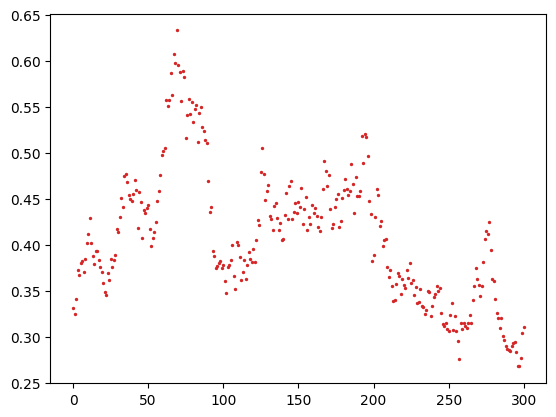

In [13]:
plt.scatter(
        t_range,
        jnp.exp(full_state[:,-1]).T,
        color="tab:red",
        s = 2.0,
        zorder=100
    )

In [14]:
def likelihood(particles,observation): 
    return jax.scipy.stats.poisson.logpmf(observation, mu = particles[:,1])

In [15]:
from algorithms.smc import particle_filter 

def data_map(theta, key):
    num_particles = 100
    key, init_key = jax.random.split(key)
    I_x0 = jax.random.randint(init_key, minval=0, maxval=20, shape=(num_particles,))

    particles = jnp.full(shape=(num_particles, 4), fill_value=jnp.array([5000., 0., 0., 0.]))
    beta_x0 = jax.random.uniform(beta_init_key, shape=(num_particles,), minval=0.1, maxval=0.5)

    particles = particles.at[:, 0].set(particles[:, 0] - I_x0)
    particles = particles.at[:, 1].set(particles[:, 1] + I_x0)

    particles = particles.at[:,3].set(jnp.log(beta_x0))

    particles, weights = particle_filter(
        model,
        observations,
        particles,
        key,
        likelihood,
        theta,
        jnp.linspace(0, 1, 2),
    )

    return jnp.mean(particles[:,:,1],axis = 0)

In [16]:
test_runs = 100
test_key,rng_key = jax.random.split(rng_key)
test_keys = jax.random.split(test_key,test_runs)
test_runs = jax.vmap(data_map,in_axes = (None,0))(theta,test_keys)

test_std = jnp.std(test_runs,axis = 0)

print(f"Average deviation: {jnp.mean(test_std)}")

Average deviation: 1.0080811977386475


In [17]:
uncertainty_factor = 0.15

gamma = uncertainty_factor * (observations**2) * jnp.eye(len(observations))

# temporal_distance_matrix = (
# jnp.abs(t_range[..., jnp.newaxis] - t_range[..., jnp.newaxis].T)
# )

# length_scale = 5.0

# Sigma = uncertainty_factor * jnp.exp(-(temporal_distance_matrix**2) / (2 * length_scale**2))

# gamma = Sigma + gamma

# plt.imshow(Sigma, cmap="inferno")
# plt.colorbar()
# plt.show()

In [18]:
from algorithms.EKI import EnsembleKalmanInversion

rng_key, noise_key = jax.random.split(rng_key)

dim_output = 3

num_ensemble_members = 25

rng_key, init_ensemble_key, init_key = jax.random.split(rng_key, 3)

num_runs = 1
init_keys = jax.random.split(init_key, num_runs)
init_scale = 0.5

initial_ensemble = jnp.full(
    shape=(num_runs, num_ensemble_members, dim_output),
    fill_value=jnp.log(jnp.array([0.4, 1 / 30, 0.4])),
) + init_scale * jax.random.normal(init_ensemble_key, (num_runs, num_ensemble_members, dim_output))

(final_ensemble, _), _ = jax.vmap(
    EnsembleKalmanInversion, in_axes=(0, None, None, None, None, 0)
)(
    initial_ensemble,
    observations,
    gamma,
    lambda x, y: jax.vmap(data_map, in_axes=(0, 0))(x, y),
    0.01,
    init_keys
)

par_estimate = jnp.mean(jnp.mean(final_ensemble, axis=0), axis=0)

print(f"Parameter Estimate: {jnp.exp(par_estimate)}")
print(f"Parameter True: {jnp.exp(theta)}")

Parameter Estimate: [0.27316976 0.02955173 0.3045974 ]
Parameter True: [0.19999999 0.01111111 0.45      ]
